# Explorative Data Analysis

In [1]:
# Import

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import skew

In [2]:
# load dataset

df = pd.read_csv('../01_data/02_processed_data/customer_profile.csv')

print(df.shape)
df.head()

(5879, 29)


,CustomerID,recency,frequency,monetary,weekend_share,avg_purchase_hour,preferred_hour,preferred_weekday,active_purchase_days,preferred_time_5cat,...,text_svd_05,text_svd_06,text_svd_07,text_svd_08,text_svd_09,text_svd_10,text_svd_11,text_svd_12,text_svd_13,text_svd_14
0,12346.0,326,12,77556.46,0.000,10.833333,13,0,8,midday,...,-0.054787,-0.021104,0.195492,0.084543,0.104115,-0.240231,0.245742,0.311689,0.199950,-0.054729
1,12347.0,2,8,5633.32,0.125,12.500000,14,1,8,afternoon,...,-0.112825,0.064833,-0.152168,0.155788,-0.040855,-0.156677,0.061693,-0.027149,-0.060058,0.173658
2,12348.0,75,5,2019.40,0.200,13.200000,10,1,5,midday,...,-0.161823,0.537691,-0.191536,0.081759,-0.091979,0.089767,-0.054764,0.083323,0.009273,0.111751
3,12349.0,19,4,4428.69,0.000,9.750000,9,3,4,morning,...,-0.186275,-0.166294,0.324660,-0.083427,0.013956,-0.200510,0.100400,0.139637,-0.129949,-0.048644
4,12350.0,310,1,334.40,0.000,16.000000,16,2,1,afternoon,...,0.124714,-0.115467,0.113825,-0.004743,-0.085082,0.096691,0.024741,-0.027823,-0.030778,-0.002321


In [3]:
# sns.pairplot(df, hue='recency')

In [4]:
# sns.pairplot(df, hue='frequency')

In [5]:
# sns.pairplot(df, hue='monetary')

### Recency - Frequency - Monetary

recency
count    5879.000000
mean      201.297840
std       209.337205
min         1.000000
50%        96.000000
75%       380.000000
90%       535.000000
95%       625.000000
99%       726.000000
max       739.000000
Name: recency, dtype: float64
frequency
count    5879.000000
mean        6.816976
std        42.492965
min         1.000000
50%         3.000000
75%         7.000000
90%        13.000000
95%        21.000000
99%        46.220000
max      3108.000000
Name: frequency, dtype: float64
monetary
count    5.879000e+03
mean     3.567374e+03
std      4.458180e+04
min      2.950000e+00
50%      8.989600e+02
75%      2.309050e+03
90%      5.597554e+03
95%      9.569588e+03
99%      3.049612e+04
max      3.229165e+06
Name: monetary, dtype: float64


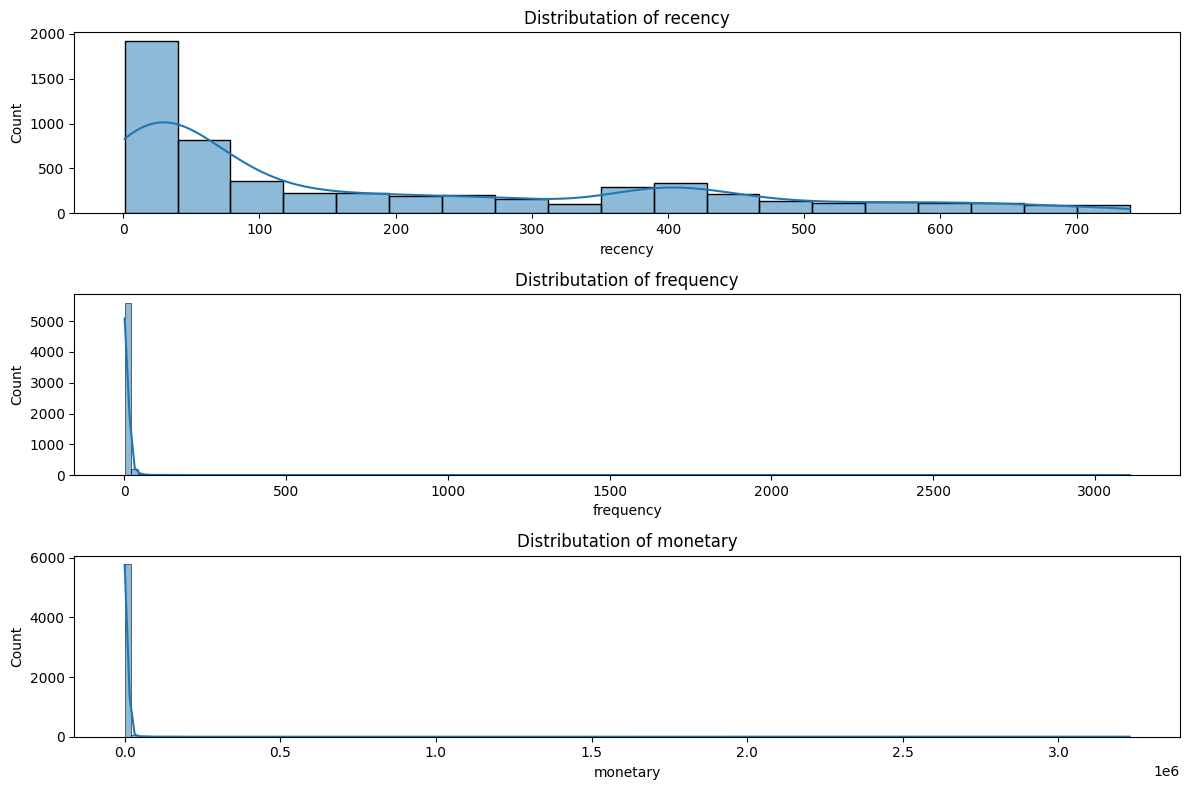

In [6]:
# Distributation rfm

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

rfm = ['recency', 'frequency', 'monetary']

for i, col in enumerate(rfm): 
    sns.histplot(data=df, x= col,kde=True, ax=axes[i])
    axes[i].set_title(f'Distributation of {col}')
    print(col)
    print(df[col].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]))

plt.tight_layout()
plt.show()

# very skewed distributions as typical for rfm

recency_log
count    5879.000000
mean        4.453492
std         1.560043
min         0.693147
25%         3.295837
50%         4.574711
75%         5.942799
max         6.606650
Name: recency_log, dtype: float64
##############
frequency_log
count    5879.000000
mean        1.550692
std         0.813796
min         0.693147
25%         0.693147
50%         1.386294
75%         2.079442
max         8.042056
Name: frequency_log, dtype: float64
##############
monetary_log
count    5879.000000
mean        6.837936
std         1.391812
min         1.373716
25%         5.857290
50%         6.802350
75%         7.745024
max        14.987735
Name: monetary_log, dtype: float64
##############
['recency_log', 'frequency_log', 'monetary_log']


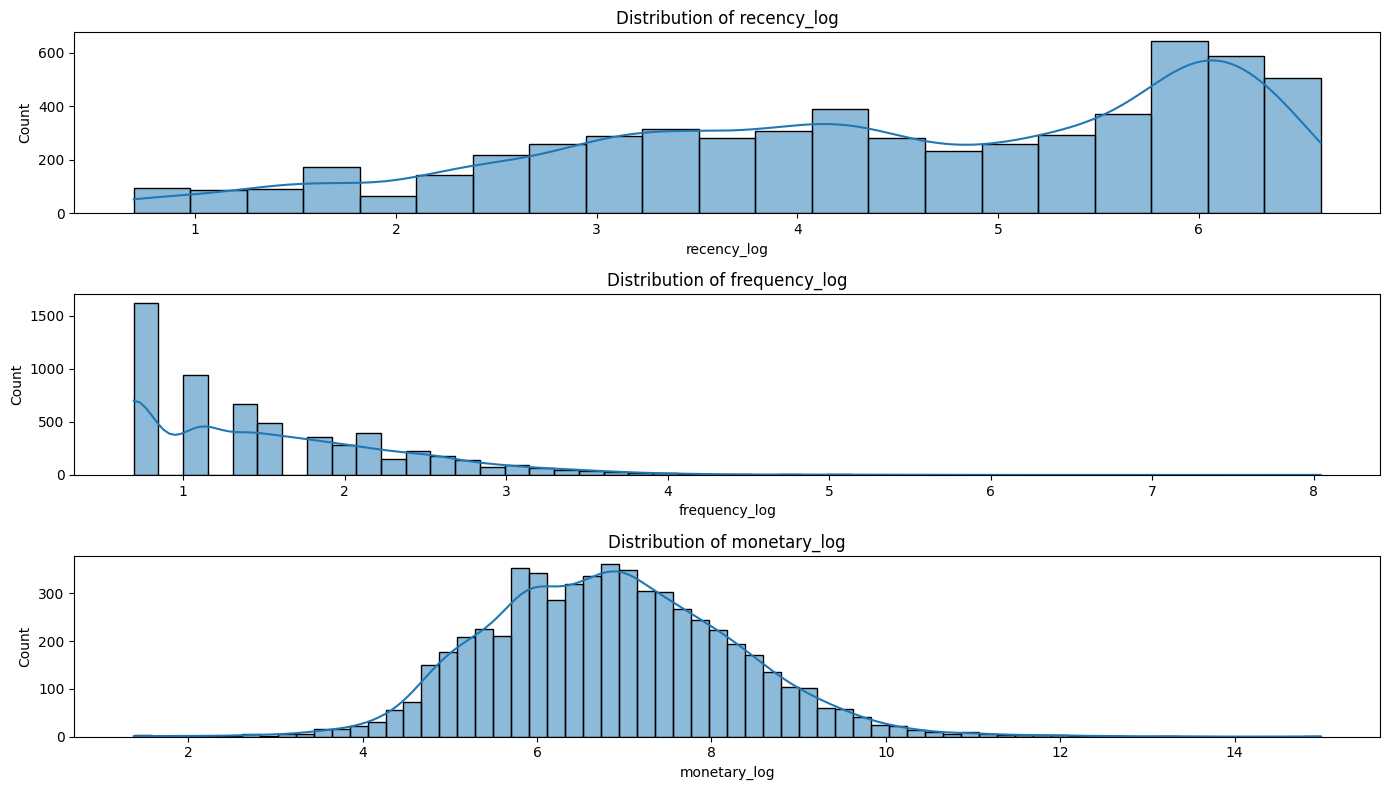

In [7]:
rfm_log=[]

for col in rfm: 
    new_col = f"{col}_log"
    df[new_col] = np.log1p(df[col])
    rfm_log.append(new_col)
    print(new_col)
    print(df[new_col].describe())
    print('##############')

print(rfm_log)

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

for i, col in enumerate(rfm_log): 
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [8]:
for col in rfm_log:
    print(col, skew(df[col].dropna()))

# acceptable with StandardScaler

recency_log -0.4889770745757959
frequency_log 1.0674078185410862
monetary_log 0.29393902954626355


            recency  frequency  monetary
recency    1.000000  -0.090555 -0.053121
frequency -0.090555   1.000000  0.962184
monetary  -0.053121   0.962184  1.000000


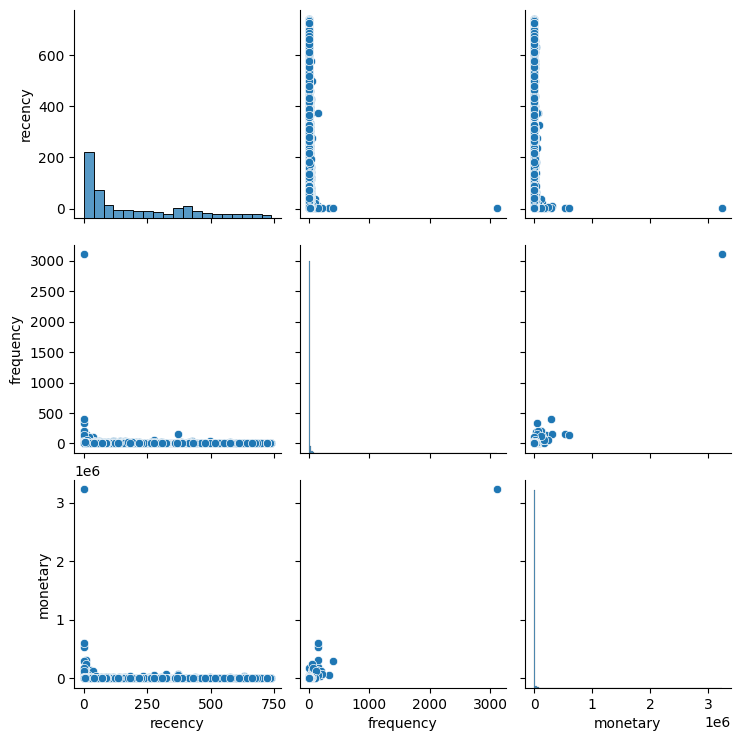

In [9]:
print(df[rfm].corr())
sns.pairplot(df[rfm])

<Axes: xlabel='recency_log', ylabel='frequency_log'>

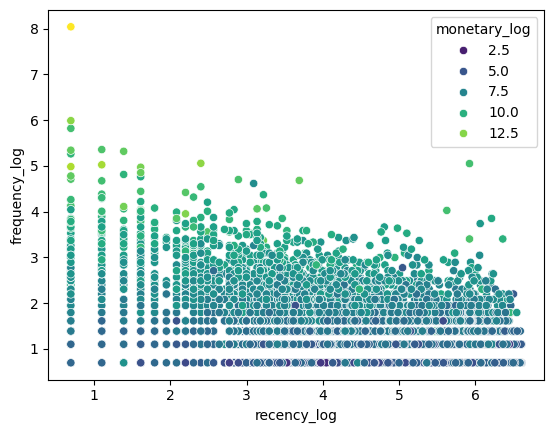

In [10]:
sns.scatterplot(
    data=df,
    x='recency_log',
    y='frequency_log',
    hue='monetary_log',
    palette='viridis'
)

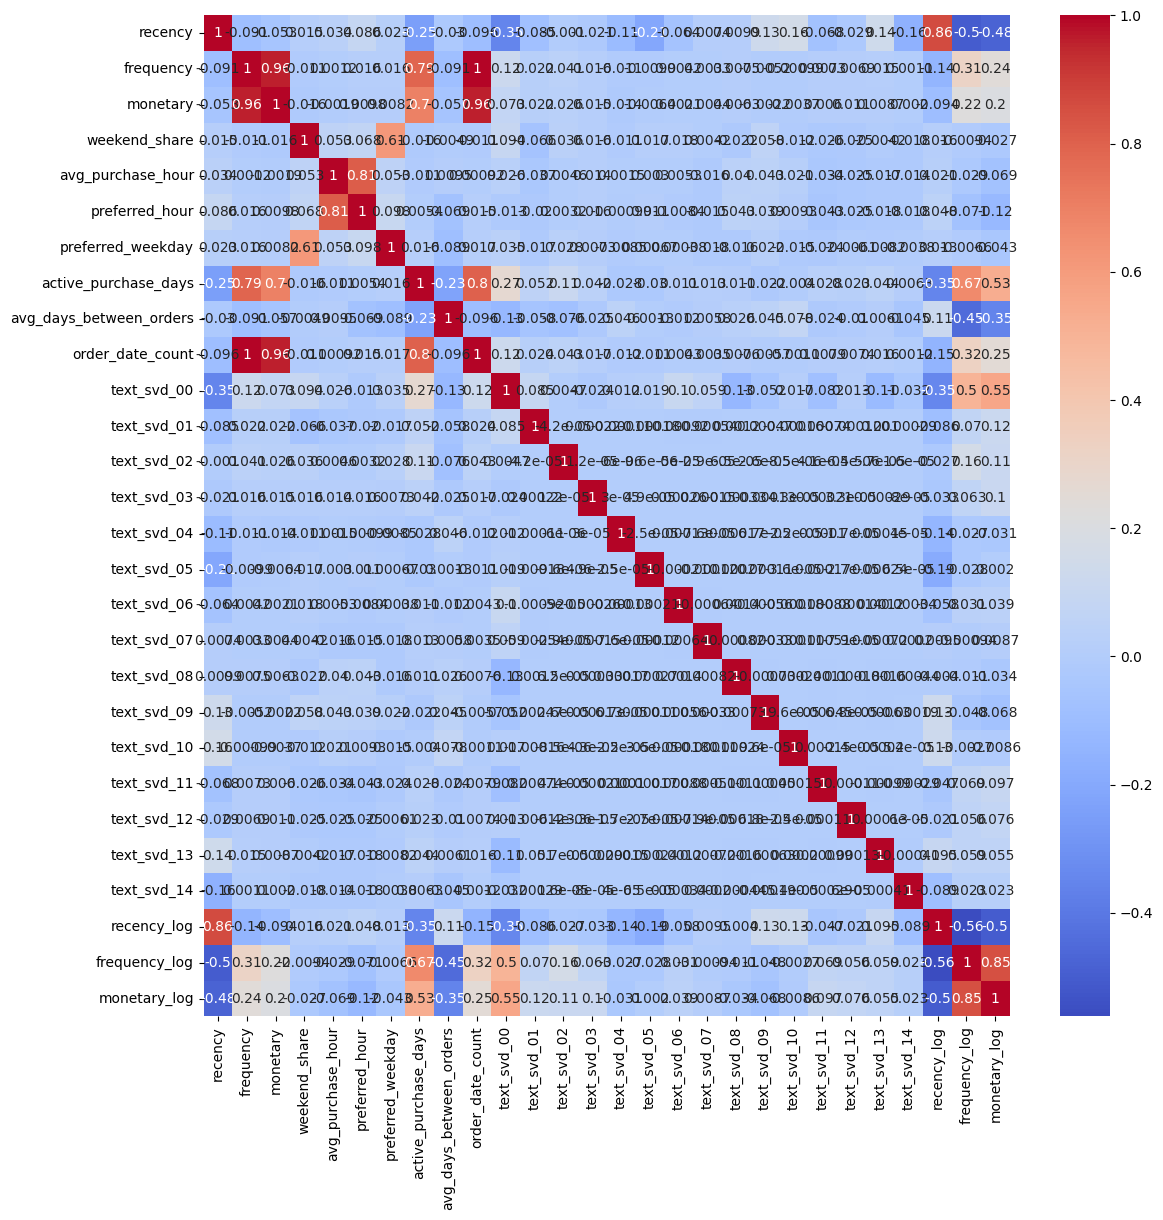

In [11]:
# Corellation Heatmap

fig, ax = plt.subplots(figsize=(13, 13))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [12]:
df.isna().sum()

CustomerID                    0
recency                       0
frequency                     0
monetary                      0
weekend_share                 0
avg_purchase_hour             0
preferred_hour                0
preferred_weekday             0
active_purchase_days          0
preferred_time_5cat           0
preferred_season              0
preferred_month_period        0
avg_days_between_orders    1625
order_date_count              0
text_svd_00                   0
text_svd_01                   0
text_svd_02                   0
text_svd_03                   0
text_svd_04                   0
text_svd_05                   0
text_svd_06                   0
text_svd_07                   0
text_svd_08                   0
text_svd_09                   0
text_svd_10                   0
text_svd_11                   0
text_svd_12                   0
text_svd_13                   0
text_svd_14                   0
recency_log                   0
frequency_log                 0
monetary

### Outlier detection

In [13]:
rfm = ["recency", "frequency", "monetary"]

df[rfm].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

,count,mean,std,min,1%,25%,50%,75%,90%,95%,99%,max
recency,5879.0,201.297840,209.337205,1.00,1.000,26.000,96.00,380.00,535.000,625.000,726.0000,739.00
frequency,5879.0,6.816976,42.492965,1.00,1.000,1.000,3.00,7.00,13.000,21.000,46.2200,3108.00
monetary,5879.0,3567.374480,44581.798840,2.95,46.851,348.775,898.96,2309.05,5597.554,9569.588,30496.1214,3229165.39


In [14]:
def iqr_limits(data, column, factor=1.5):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - factor * iqr
    upper = q3 + factor * iqr

    return lower, upper

for col in rfm:
    lower, upper = iqr_limits(df, col)
    print(f"{col}:")
    print(f"  Lower limit: {lower:.2f}")
    print(f"  Upper limit: {upper:.2f}")
    print(f"  Outliers:      {((df[col] < lower) | (df[col] > upper)).sum()}")

recency:
  Lower limit: -505.00
  Upper limit: 911.00
  Outliers:      0
frequency:
  Lower limit: -8.00
  Upper limit: 16.00
  Outliers:      428
monetary:
  Lower limit: -2591.64
  Upper limit: 5249.46
  Outliers:      628


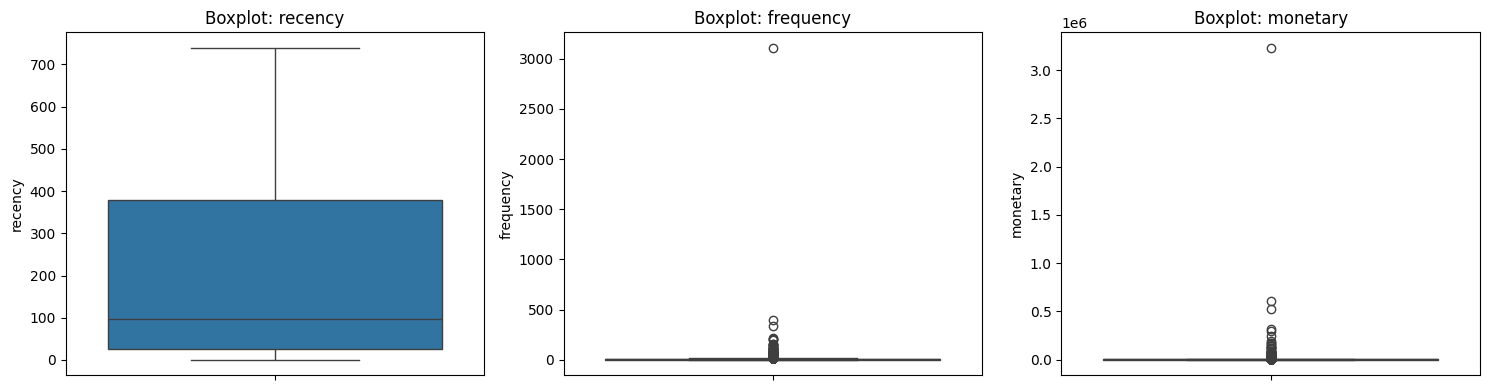

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, rfm):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

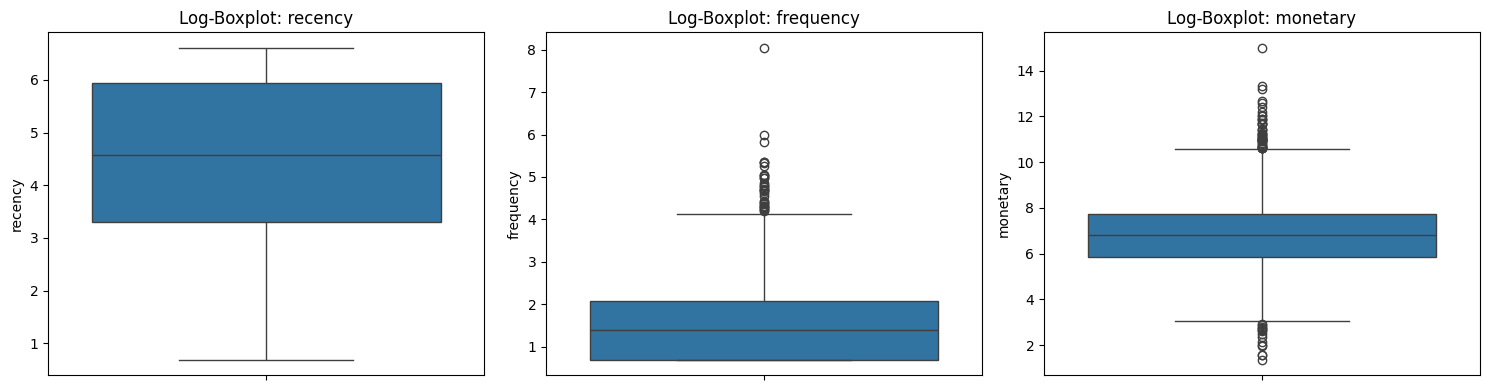

In [16]:
df_plot = df[rfm].copy()

for col in rfm:
    df_plot[col] = np.log1p(df_plot[col])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, rfm):
    sns.boxplot(y=df_plot[col], ax=ax)
    ax.set_title(f"Log-Boxplot: {col}")

plt.tight_layout()
plt.show()

In [17]:
df.nlargest(10, "monetary")[
    ["CustomerID", "recency", "frequency", "monetary"]
]

,CustomerID,recency,frequency,monetary
5878,Unknown,1,3108,3229165.39
5692,18102.0,1,145,608821.65
2277,14646.0,2,151,528602.52
1789,14156.0,10,156,313946.37
2538,14911.0,1,398,295972.63
5050,17450.0,8,51,246973.09
1331,13694.0,4,143,196482.81
5109,17511.0,3,60,175603.55
4061,16446.0,1,2,168472.50
4295,16684.0,4,55,147142.77


In [18]:
df.nlargest(10, "frequency")[
    ["CustomerID", "recency", "frequency", "monetary"]
]

,CustomerID,recency,frequency,monetary
5878,Unknown,1,3108,3229165.39
2538,14911.0,1,398,295972.63
400,12748.0,1,336,56599.39
5433,17841.0,2,211,70884.07
2935,15311.0,1,208,116771.16
739,13089.0,3,203,116737.86
2237,14606.0,1,192,30861.06
1789,14156.0,10,156,313946.37
5442,17850.0,372,155,56600.08
2277,14646.0,2,151,528602.52


In [19]:
# Remove Unknown CustomerID

df=df[df["CustomerID"].ne("Unknown")].copy()

recency
count    5878.000000
mean      201.331916
std       209.338707
min         1.000000
50%        96.000000
75%       380.000000
90%       535.000000
95%       625.000000
99%       726.000000
max       739.000000
Name: recency, dtype: float64
frequency
count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
50%         3.000000
75%         7.000000
90%        13.000000
95%        21.000000
99%        46.000000
max       398.000000
Name: frequency, dtype: float64
monetary
count      5878.000000
mean       3018.616737
std       14737.731040
min           2.950000
50%         898.915000
75%        2307.090000
90%        5595.365000
95%        9535.336000
99%       29730.420200
max      608821.650000
Name: monetary, dtype: float64


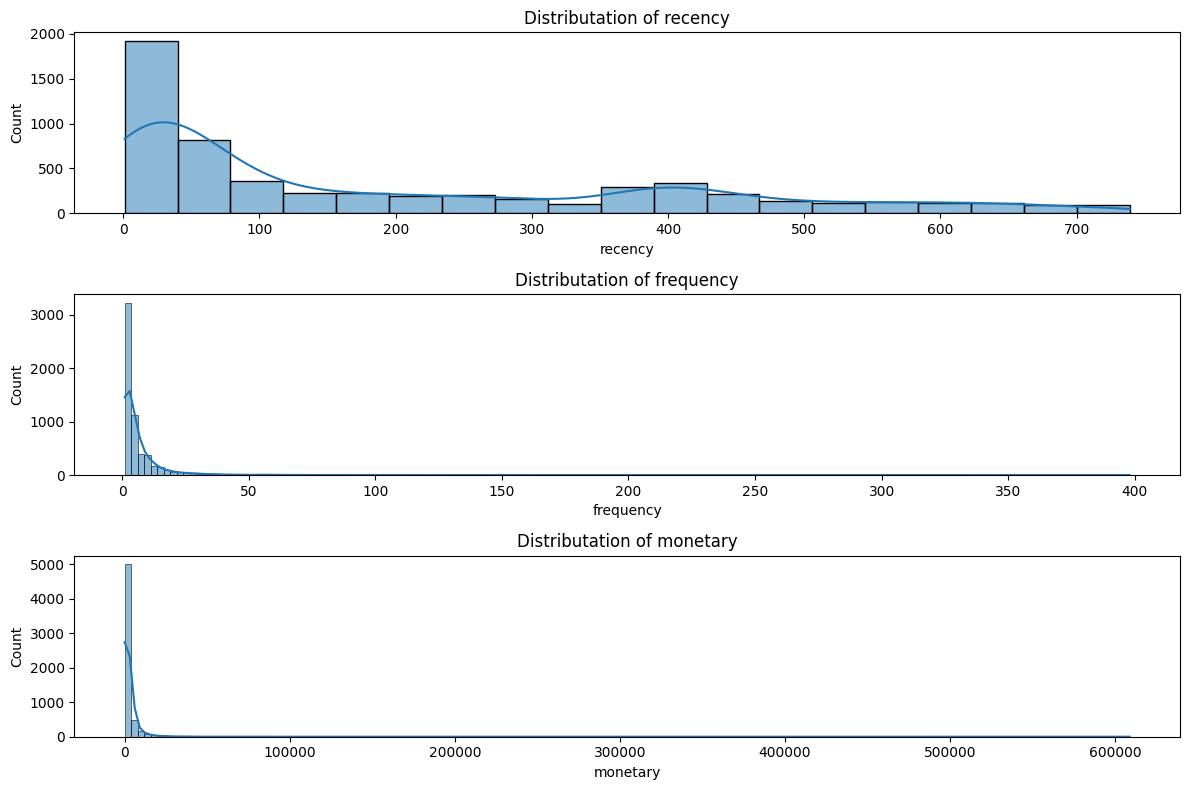

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

for i, col in enumerate(rfm): 
    sns.histplot(data=df, x= col,kde=True, ax=axes[i])
    axes[i].set_title(f'Distributation of {col}')
    print(col)
    print(df[col].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]))

plt.tight_layout()
plt.show()

In [23]:
# Cap Outliers at 99th Percentile

df_rfm_cap = df.copy()

for col in rfm:
    upper = df_rfm_cap[col].quantile(0.99)
    df_rfm_cap[col] = df_rfm_cap[col].clip(upper=upper)

In [24]:
pd.DataFrame({
    "original_max": df[rfm].max(),
    "p99_limit": df[rfm].quantile(0.99),
    "new_max": df_rfm_cap[rfm].max()
})

,original_max,p99_limit,new_max
recency,739.00,726.0000,726.0000
frequency,398.00,46.0000,46.0000
monetary,608821.65,29730.4202,29730.4202


In [25]:
rfm_log_cap = []

for col in rfm:
    new_col = f"{col}_log_cap"
    df_rfm_cap[new_col] = np.log1p(df_rfm_cap[col])
    rfm_log_cap.append(new_col)

In [26]:
pd.DataFrame({
    "original_max": df[rfm_log].max(),
    "p99_limit": df[rfm_log].quantile(0.99),
    "new_max": df_rfm_cap[rfm_log].max()
})

,original_max,p99_limit,new_max
recency_log,6.606650,6.588926,6.606650
frequency_log,5.988961,3.850148,5.988961
monetary_log,13.319282,10.299886,13.319282


### Preferred time

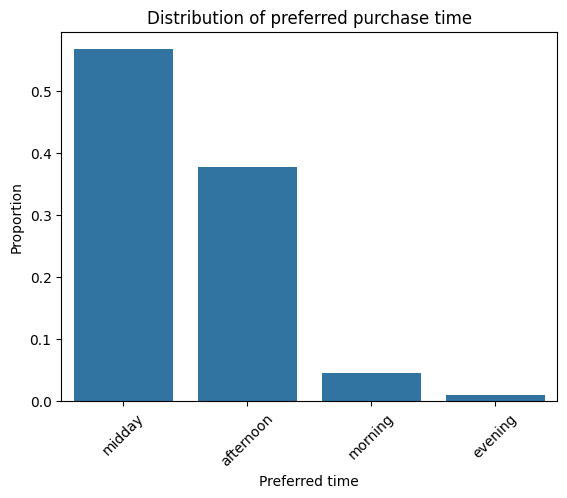

In [27]:
# Distribution Preferred Purchase Time

percentages = df['preferred_time_5cat'].value_counts(normalize=True)

sns.barplot(x=percentages.index, y=percentages.values)
plt.xlabel('Preferred time')
plt.ylabel('Proportion')
plt.title('Distribution of preferred purchase time')
plt.xticks(rotation=45)
plt.show()


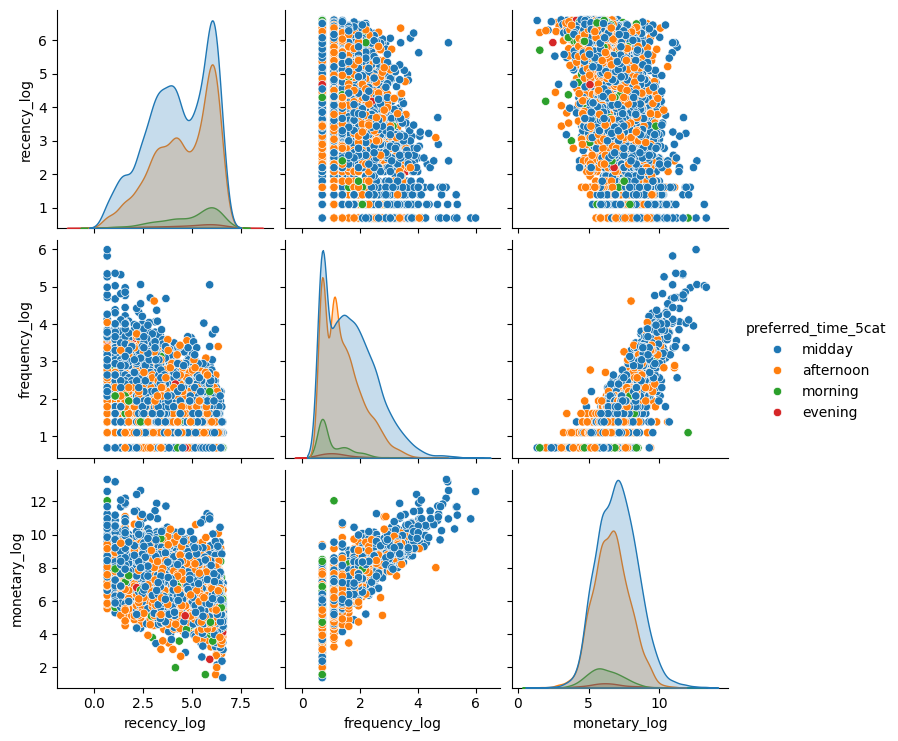

In [28]:
sns.pairplot(
    data=df[
        ['recency_log', 'frequency_log', 'monetary_log', 'preferred_time_5cat']
    ],
    hue='preferred_time_5cat'
)

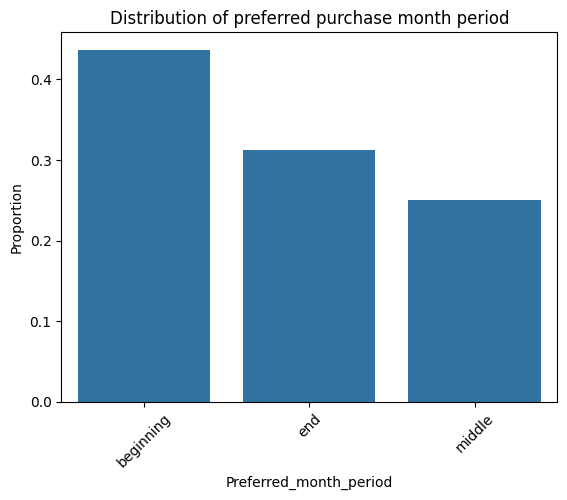

In [29]:
# Distribution Preferred Purchase Month Period

percentages = df['preferred_month_period'].value_counts(normalize=True)

sns.barplot(x=percentages.index, y=percentages.values)
plt.xlabel('Preferred_month_period')
plt.ylabel('Proportion')
plt.title('Distribution of preferred purchase month period')
plt.xticks(rotation=45)
plt.show()

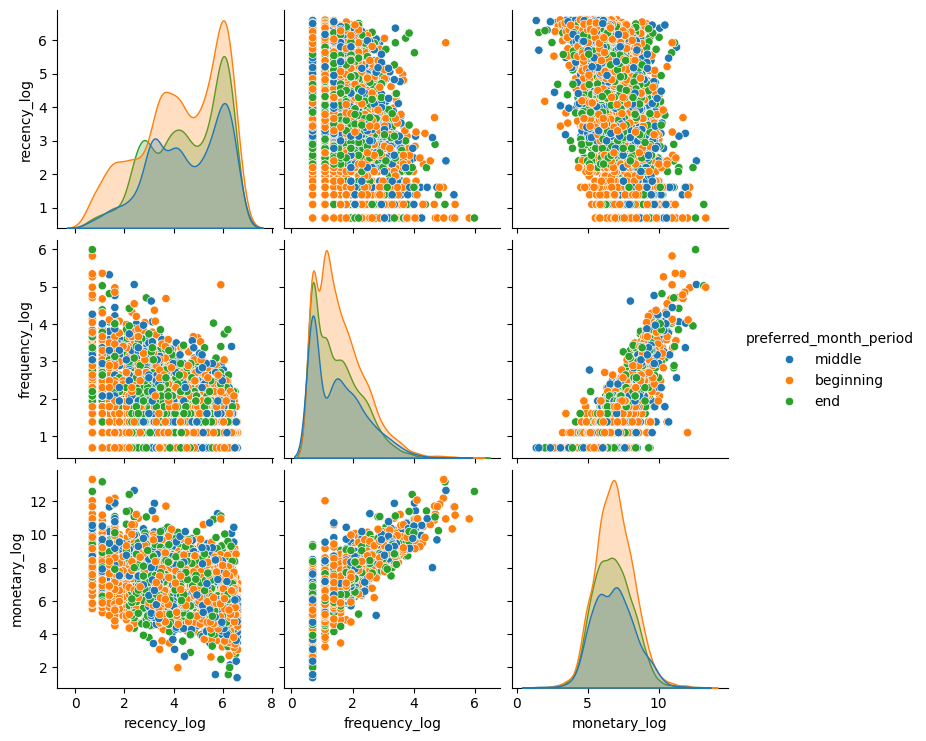

In [30]:
sns.pairplot(
    data=df[
        ['recency_log', 'frequency_log', 'monetary_log', 'preferred_month_period']
    ],
    hue='preferred_month_period'
)

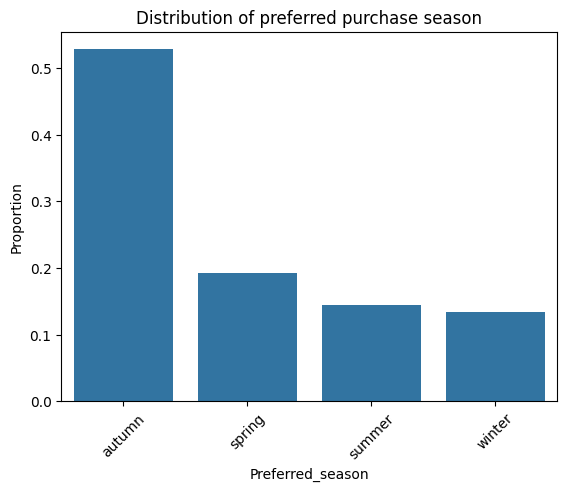

In [31]:
# Distribution Preferred Purchase Season

percentages = df['preferred_season'].value_counts(normalize=True)

sns.barplot(x=percentages.index, y=percentages.values)
plt.xlabel('Preferred_season')
plt.ylabel('Proportion')
plt.title('Distribution of preferred purchase season')
plt.xticks(rotation=45)
plt.show()

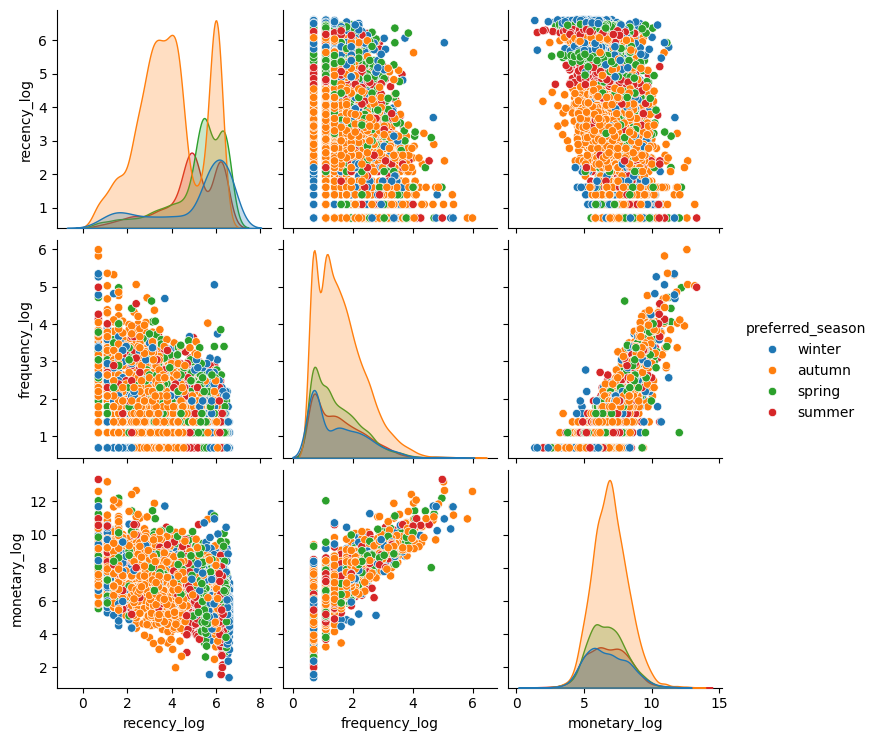

In [32]:
sns.pairplot(
    data=df[
        ['recency_log', 'frequency_log', 'monetary_log', 'preferred_season']
    ],
    hue='preferred_season'
)

In [33]:
# Purchased Rythm

print(df['avg_days_between_orders'].describe())
print(df['order_date_count'].describe())

count    4253.000000
mean      102.583895
std        98.453082
min         0.000694
25%        38.838194
50%        72.592052
75%       129.990972
max       714.152083
Name: avg_days_between_orders, dtype: float64
count    5878.000000
mean        6.258591
std        12.896355
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       396.000000
Name: order_date_count, dtype: float64


In [34]:
# Save DataFrame to csv

df_rfm_cap.to_csv('../01_data/02_processed_data/customer_profile_rfm_cap.csv', index=False)
